# Traffic features

This notebook cleans the raw traffic files and aggregates them to street level. Output: `data/derived/traffic_agg.csv`.


In [1]:
from street_normalize import normalize

In [2]:
import pandas as pd

traffic_1 = pd.read_csv("data/raw/traffic/traffic_1.csv")
traffic_2 = pd.read_csv("data/raw/traffic/traffic_2.csv")

In [3]:
traffic = pd.concat([traffic_1,traffic_2], ignore_index = True)

In [4]:
boro_dct = {'Manhattan': '1', 'Bronx': '2', 'Brooklyn':'3', 'Queens':'4', 'Staten Island':'5'}

In [5]:
traffic['HH'].unique()

array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,  0,
        1,  2,  3,  4,  5,  6,  7])

In [6]:
traffic['Yr'].unique()

array([2016, 2023, 2018, 2025, 2022, 2021, 2017, 2024, 2019, 2015, 2020])

In [7]:
traffic['HH'].apply(type).unique()

array([<class 'int'>], dtype=object)

stick to normal hours

In [8]:
traffic = traffic[(traffic['HH'] >= 8) & (traffic['HH'] <= 20)]


In [9]:
traffic['normalized_street_name'] = traffic.apply(
    lambda row: f"{boro_dct.get(row['Boro'], '')}-{normalize(row['street'])}",
    axis=1
)

In [10]:
traffic.head(20)

,Unnamed: 0,RequestID,Boro,Yr,M,D,HH,MM,Vol,SegmentID,WktGeom,street,fromSt,toSt,Direction,normalized_street_name
0,0,22562,Queens,2016,5,8,8,45,260,155613,POINT (1059678.8154876027 198480.09766927382),HEMPSTEAD AVENUE,Cross Island Parkway,Cross Is Pkwy Nb En Hempstead Wb,WB,4-hempstead avenue
1,1,22562,Queens,2016,5,8,9,0,243,155613,POINT (1059678.8154876027 198480.09766927382),HEMPSTEAD AVENUE,Cross Island Parkway,Cross Is Pkwy Nb En Hempstead Wb,WB,4-hempstead avenue
2,2,22562,Queens,2016,5,8,9,15,245,155613,POINT (1059678.8154876027 198480.09766927382),HEMPSTEAD AVENUE,Cross Island Parkway,Cross Is Pkwy Nb En Hempstead Wb,WB,4-hempstead avenue
3,3,22562,Queens,2016,5,8,9,30,304,155613,POINT (1059678.8154876027 198480.09766927382),HEMPSTEAD AVENUE,Cross Island Parkway,Cross Is Pkwy Nb En Hempstead Wb,WB,4-hempstead avenue
4,4,22562,Queens,2016,5,8,9,45,312,155613,POINT (1059678.8154876027 198480.09766927382),HEMPSTEAD AVENUE,Cross Island Parkway,Cross Is Pkwy Nb En Hempstead Wb,WB,4-hempstead avenue
5,5,22562,Queens,2016,5,8,10,0,331,155613,POINT (1059678.8154876027 198480.09766927382),HEMPSTEAD AVENUE,Cross Island Parkway,Cross Is Pkwy Nb En Hempstead Wb,WB,4-hempstead avenue
6,6,22562,Queens,2016,5,8,10,15,331,155613,POINT (1059678.8154876027 198480.09766927382),HEMPSTEAD AVENUE,Cross Island Parkway,Cross Is Pkwy Nb En Hempstead Wb,WB,4-hempstead avenue
7,7,22562,Queens,2016,5,8,10,30,344,155613,POINT (1059678.8154876027 198480.09766927382),HEMPSTEAD AVENUE,Cross Island Parkway,Cross Is Pkwy Nb En Hempstead Wb,WB,4-hempstead avenue
8,8,22562,Queens,2016,5,8,10,45,397,155613,POINT (1059678.8154876027 198480.09766927382),HEMPSTEAD AVENUE,Cross Island Parkway,Cross Is Pkwy Nb En Hempstead Wb,WB,4-hempstead avenue
9,9,22562,Queens,2016,5,8,11,0,356,155613,POINT (1059678.8154876027 198480.09766927382),HEMPSTEAD AVENUE,Cross Island Parkway,Cross Is Pkwy Nb En Hempstead Wb,WB,4-hempstead avenue


In [11]:
traffic['M'].unique()

array([ 5,  1,  4,  6,  3, 12,  7, 10,  9,  2, 11,  8])

In [12]:
traffic = traffic[['Yr', 'Vol', 'normalized_street_name']]

traffic = (
    traffic.groupby(['normalized_street_name'], as_index=False)['Vol']
    .mean()
)


In [13]:
traffic.head(20)

,normalized_street_name,Vol
0,1-1 avenue,221.774084
1,1-10 avenue,70.393004
2,1-11 avenue,152.736511
3,1-12 avenue,662.847756
4,1-145 street bridge,191.388721
5,1-2 avenue,375.179104
6,1-3 avenue,183.484979
7,1-3 avenue bridge,0.000000
8,1-5 avenue,255.882711
9,1-6 avenue,371.210852


In [14]:
traffic[traffic['Vol'] == 0]

,normalized_street_name,Vol
7,1-3 avenue bridge,0.0
207,2-henry hudson parkway,0.0
334,3-belt parkway wb en rockaway parkway,0.0
655,4-cherry avenue,0.0


In [15]:
traffic = traffic[traffic['Vol'] != 0]

In [16]:
traffic['normalized_street_name'].nunique()

818

In [17]:
traffic[traffic['normalized_street_name'] == '1-east 125 street']

,normalized_street_name,Vol
42,1-east 125 street,31.111111


In [18]:
traffic.to_csv("data/derived/traffic_agg.csv", index=False)

In [19]:
print(traffic['Vol'].min(), traffic['Vol'].max())

0.9041666666666667 1264.082262210797


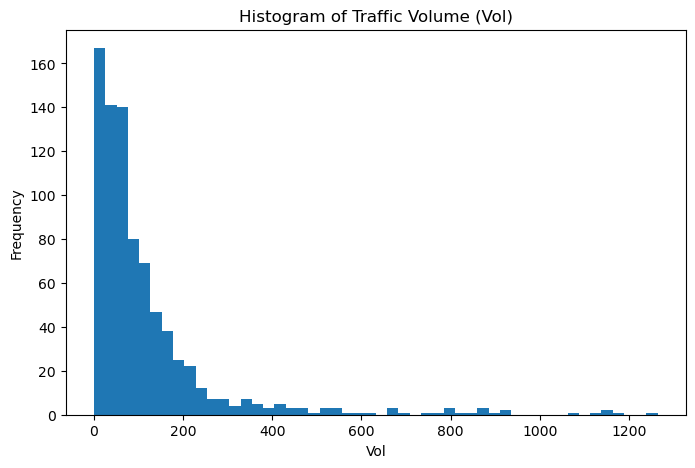

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(traffic['Vol'], bins=50)
plt.xlabel("Vol")
plt.ylabel("Frequency")
plt.title("Histogram of Traffic Volume (Vol)")
plt.show()
